In [87]:

import pandas as pd

✅ Best Params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
✅ Best Score: 0.984659090909091


In [89]:
df=pd.read_csv("Crop_recommendation.csv")
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [90]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [92]:
#catergrical variable lebels
df['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [93]:
y=df['label']
X=df.drop('label',axis=1)

In [94]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 120.4 KB


In [95]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 2200 entries, 0 to 2199
Series name: label
Non-Null Count  Dtype 
--------------  ----- 
2200 non-null   object
dtypes: object(1)
memory usage: 17.3+ KB


In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [97]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1760 entries, 1863 to 1061
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            1760 non-null   int64  
 1   P            1760 non-null   int64  
 2   K            1760 non-null   int64  
 3   temperature  1760 non-null   float64
 4   humidity     1760 non-null   float64
 5   ph           1760 non-null   float64
 6   rainfall     1760 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 110.0 KB


In [98]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [99]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440 entries, 1276 to 1263
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            440 non-null    int64  
 1   P            440 non-null    int64  
 2   K            440 non-null    int64  
 3   temperature  440 non-null    float64
 4   humidity     440 non-null    float64
 5   ph           440 non-null    float64
 6   rainfall     440 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 27.5 KB


In [100]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 1760 entries, 1863 to 1061
Series name: label
Non-Null Count  Dtype 
--------------  ----- 
1760 non-null   object
dtypes: object(1)
memory usage: 27.5+ KB


In [101]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 440 entries, 1276 to 1263
Series name: label
Non-Null Count  Dtype 
--------------  ----- 
440 non-null    object
dtypes: object(1)
memory usage: 6.9+ KB


### now will see what model is suited for the dataset

In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred = log_reg.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Logistic Regression: {accuracy:.2f}")

Accuracy of Logistic Regression: 0.94


In [103]:
train_acc = accuracy_score(y_train, log_reg.predict(X_train_scaled))
test_acc = accuracy_score(y_test, log_reg.predict(X_test_scaled))

print(" Train Accuracy:", train_acc)
print(" Test Accuracy:", test_acc)

 Train Accuracy: 0.9443181818181818
 Test Accuracy: 0.9386363636363636


Note: you may need to restart the kernel to use updated packages.


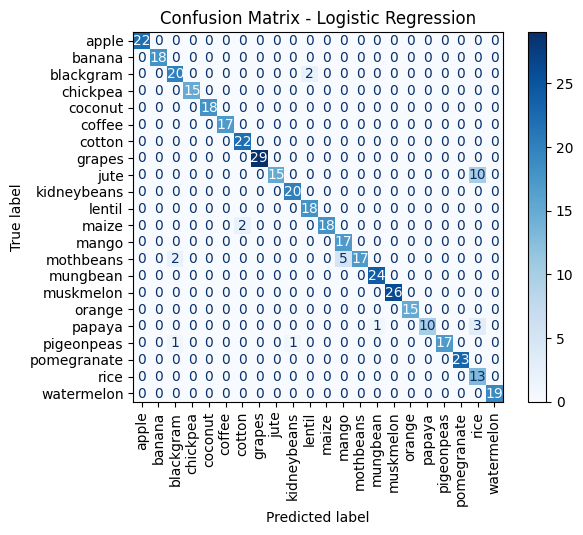

In [104]:
%pip install matplotlib

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [105]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define hyperparameters to tune
params = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Base model
dt = DecisionTreeClassifier(random_state=1)

# Grid search with accuracy scoring
grid1 = GridSearchCV(dt, params, cv=5, scoring='accuracy', n_jobs=-1)

# Train
grid1.fit(X_train_scaled, y_train)

# Best parameters
print("Best Parameters:", grid1.best_params_)

# Best model and accuracy
best_model = grid1.best_estimator_
accuracy = accuracy_score(y_test, best_model.predict(X_test_scaled))
print("Best Accuracy:", accuracy)


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Accuracy: 0.9954545454545455


In [106]:
train_acc = accuracy_score(y_train, grid1.predict(X_train_scaled))
test_acc = accuracy_score(y_test, grid1.predict(X_test_scaled))

print(" Train Accuracy:", train_acc)
print(" Test Accuracy:", test_acc)

 Train Accuracy: 0.9988636363636364
 Test Accuracy: 0.9954545454545455


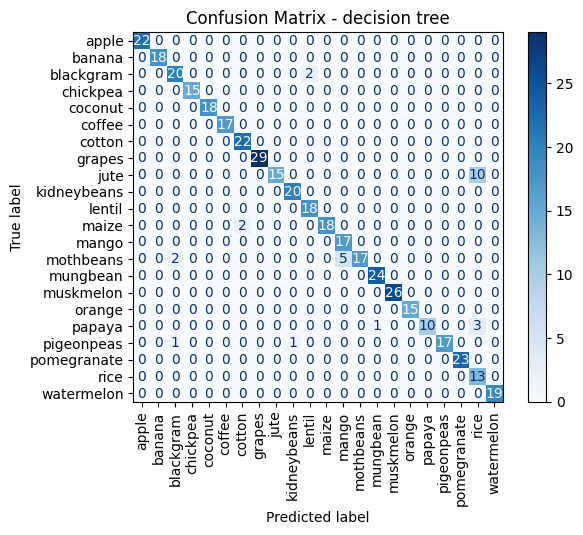

In [107]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid1.classes_)
disp.plot(xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix - decision tree")
plt.show()


In [108]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
}

grid3 = GridSearchCV(RandomForestClassifier(), params, cv=3, scoring='accuracy')
grid3.fit(X_train_scaled, y_train)

print("Best Parameters:", grid3.best_params_)
best_model = grid3.best_estimator_
print("Best Accuracy:", accuracy_score(y_test, best_model.predict(X_test_scaled)))

c:\Users\dibya\Videos\Crop Recommendation System (ML + Flask Web App)\.venv\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\dibya\Videos\Crop Recommendation System (ML + Flask Web App)\.venv\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\dibya\Videos\Crop Recommendation System (ML + Flask Web App)\.venv\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_target(classes)
c:\Users\dibya\Videos\Crop Recommendation System (ML + Flask Web App)\.venv\Lib\site-packages\sklearn\utils\_response.py:203: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  target_type = type_of_

Best Parameters: {'max_depth': 10, 'n_estimators': 200}
Best Accuracy: 0.9977272727272727


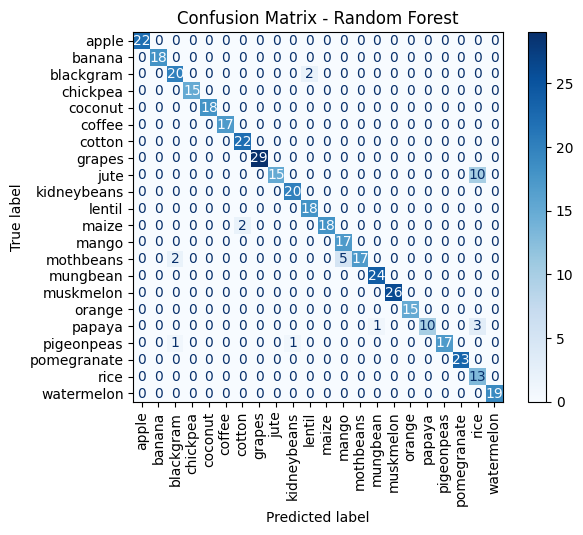

In [109]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid3.classes_)
disp.plot(xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [110]:
from sklearn.ensemble import RandomForestClassifier
model= RandomForestClassifier(max_depth=None, n_estimators=200,random_state=1)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Random Forest: {accuracy}")
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc = accuracy_score(y_test, model.predict(X_test_scaled))

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Accuracy of Random Forest: 0.9977272727272727
Train Accuracy: 1.0
Test Accuracy: 0.9977272727272727


In [111]:
##here accuracy of rendom forest is better than decision tree and logistic regression
#so we will use random forest as our final model
import joblib
joblib.dump(model, 'crop_recommendation_model.pkl')


['crop_recommendation_model.pkl']

In [112]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']